# Lab 3 - Four Estimators, One Question

*SDAIA Academy · Experimentation and Causal Inference · SOLUTION notebook*

## Objective
Estimate the same treatment effect four ways on one observational dataset with known ground truth, add a quasi-experimental design on a second dataset, and reconcile the spread by naming the assumption each estimate relies on.

Question: **Did the voluntary digital-literacy training programme raise service completion?** (`injaz_users.csv`, treatment `enrolled`, outcome `completed`). Enrolment was self-selected: the naive gap overstates the effect.

Second dataset: `injaz_regions_panel.csv`, the staggered region-by-region **reminder rollout** (DiD).

In [1]:
import sys; sys.path.insert(0, '..')   # so `causal_utils` is importable from starter/ or solution/
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from causal_utils import *
plt.rcParams['figure.figsize'] = (7, 3.5)
rng = np.random.default_rng(213)
DATA = '../data'

In [2]:
obs = pd.read_csv(f'{DATA}/injaz_users.csv')
naive = obs.loc[obs.enrolled==1,'completed'].mean() - obs.loc[obs.enrolled==0,'completed'].mean()
print(f'Naive difference (enrolled - not): {naive:+.4f}')
obs.head()

Naive difference (enrolled - not): +0.1208


,user_id,age,digital_literacy,region,region_code,prior_completions,device_age,distance_km,online_filing,enrolled,support_calls,completed
0,U000000,27,0.620,Qassim,3,6,0.4,18.9,1,1,1,1
1,U000001,51,0.327,Riyadh,0,4,0.9,21.9,0,1,0,0
2,U000002,40,0.463,Al Jawf,12,4,2.5,7.9,0,1,0,0
3,U000003,54,0.082,Riyadh,0,0,2.1,26.0,1,0,1,1
4,U000004,29,0.521,Eastern,4,1,2.4,27.7,1,0,1,1


## Step 1 - Draw the DAG and select the adjustment set
Assumed structure: `age`, `digital_literacy`, `prior_completions`, `region_code` are common causes of `enrolled` and `completed`. `support_calls` is caused by `enrolled` and affects `completed` (a **mediator**). `distance_km` affects `online_filing` only.

List the backdoor paths with networkx and state the adjustment set. `support_calls` must be excluded (descendant of treatment).

Backdoor paths:
   enrolled - age - completed
   enrolled - digital_literacy - completed
   enrolled - prior_completions - completed
   enrolled - region_code - completed
Adjustment set: ['age', 'digital_literacy', 'prior_completions', 'region_code'] | excluded mediator: support_calls


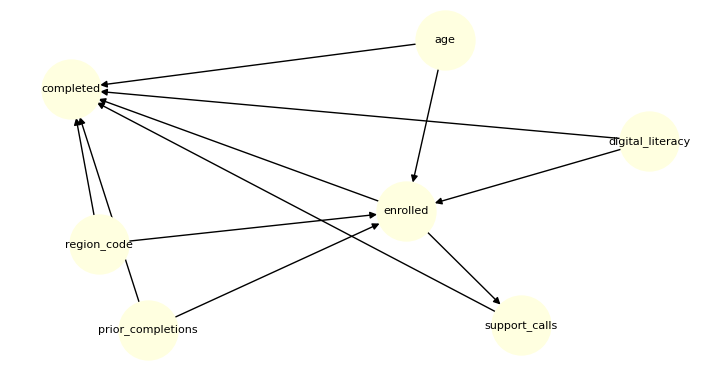

In [3]:
import networkx as nx
edges = [(c, 'enrolled') for c in ['age', 'digital_literacy', 'prior_completions', 'region_code']] + \
        [(c, 'completed') for c in ['age', 'digital_literacy', 'prior_completions', 'region_code']] + \
        [('enrolled', 'support_calls'), ('support_calls', 'completed'), ('enrolled', 'completed')]
G = nx.DiGraph(edges)
UG = G.to_undirected()
backdoor = [p for p in nx.all_simple_paths(UG, 'enrolled', 'completed') if len(p) > 2 and G.has_edge(p[1], 'enrolled')]
print("Backdoor paths:"); [print("  ", " - ".join(p)) for p in backdoor]
ADJ = ['age', 'digital_literacy', 'prior_completions', 'region_code']
print("Adjustment set:", ADJ, "| excluded mediator: support_calls")
pos = nx.spring_layout(G, seed=3); nx.draw(G, pos, with_labels=True, node_color='lightyellow', node_size=1800, font_size=8, arrows=True); plt.show()

## Step 2 - Outcome regression (g-formula)
Fit `E[Y | T, X]`, predict both potential outcomes for everyone, average the difference. Also fit the **wrong** model that adds the mediator, to see the effect shrink.

In [4]:
f_adj = 'completed ~ enrolled + age + digital_literacy + prior_completions + C(region_code)'
m = smf.ols(f_adj, data=obs).fit(cov_type='HC3')
d1, d0 = obs.assign(enrolled=1), obs.assign(enrolled=0)
g_ate = (m.predict(d1) - m.predict(d0)).mean()
print(f"g-formula ATE: {g_ate:+.4f}   (coef on enrolled {m.params['enrolled']:+.4f}, SE {m.bse['enrolled']:.4f})")
m_bad = smf.ols(f_adj + ' + support_calls', data=obs).fit(cov_type='HC3')
print(f"WRONG (mediator controlled): {m_bad.params['enrolled']:+.4f}   <- part of the effect erased")

g-formula ATE: +0.0404   (coef on enrolled +0.0404, SE 0.0073)


WRONG (mediator controlled): +0.0224   <- part of the effect erased


## Step 3 - Propensity score, overlap, stabilised IPW with trimming
Fit `e(x)` with logistic regression, plot the overlap, print the max and 99th-percentile weight, trim to common support, and check post-weighting balance (SMD < 0.1).

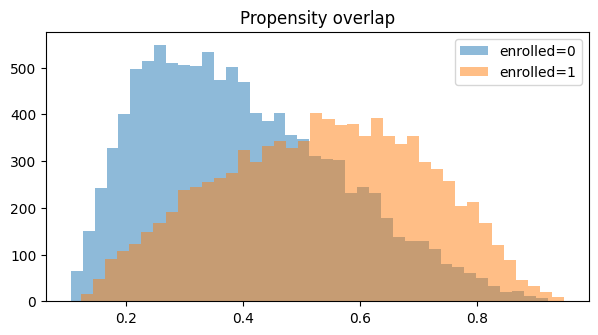

Common support [0.172, 0.812] keeps 94.3% of units
Stabilised IPW ATE: +0.0449 | max weight 2.87, 99th pct 2.38
           covariate     smd  balanced
0                age  0.0053      True
1   digital_literacy  0.0099      True
2  prior_completions  0.0195      True


In [5]:
from sklearn.linear_model import LogisticRegression
X = pd.get_dummies(obs[ADJ], columns=['region_code'], drop_first=True).astype(float)
ps = LogisticRegression(max_iter=2000).fit(X, obs['enrolled'])
obs['pscore'] = ps.predict_proba(X)[:, 1]
for arm in (0, 1):
    plt.hist(obs.loc[obs.enrolled == arm, 'pscore'], bins=40, alpha=.5, label=f'enrolled={arm}')
plt.legend(); plt.title('Propensity overlap'); plt.show()
lo, hi = obs.loc[obs.enrolled == 1, 'pscore'].quantile(.01), obs.loc[obs.enrolled == 0, 'pscore'].quantile(.99)
cs = obs[(obs.pscore >= lo) & (obs.pscore <= hi)].copy()
print(f"Common support [{lo:.3f}, {hi:.3f}] keeps {len(cs)/len(obs):.1%} of units")
ipw = ipw_ate(cs['completed'].values, cs['enrolled'].values, cs['pscore'].values, stabilised=True)
cs['w'] = ipw['weights']
print(f"Stabilised IPW ATE: {ipw['ate']:+.4f} | max weight {cs['w'].max():.2f}, 99th pct {cs['w'].quantile(.99):.2f}")
print(balance_table(cs, ['age', 'digital_literacy', 'prior_completions'], 'enrolled', weights='w'))

## Step 4 - Doubly-robust AIPW with cross-fitting
Use gradient boosting for both nuisance models, fit on one fold and predict on the other (2-fold cross-fitting), then combine with `aipw_ate`. Report the interval.

In [6]:
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.model_selection import KFold
y, t = cs['completed'].values, cs['enrolled'].values
Xc = pd.get_dummies(cs[ADJ], columns=['region_code'], drop_first=True).astype(float).values
e_hat = np.zeros(len(y)); m1 = np.zeros(len(y)); m0 = np.zeros(len(y))
for train, test in KFold(2, shuffle=True, random_state=0).split(Xc):
    pm = GradientBoostingClassifier(max_depth=3, n_estimators=150, random_state=0).fit(Xc[train], t[train])
    e_hat[test] = pm.predict_proba(Xc[test])[:, 1]
    Xt = np.column_stack([t, Xc])
    om = GradientBoostingRegressor(max_depth=3, n_estimators=150, random_state=0).fit(Xt[train], y[train])
    m1[test] = om.predict(np.column_stack([np.ones(len(test)), Xc[test]]))
    m0[test] = om.predict(np.column_stack([np.zeros(len(test)), Xc[test]]))
dr = aipw_ate(y, t, e_hat, m1, m0)
print(f"AIPW (cross-fit) ATE: {dr['ate']:+.4f}  95% CI [{dr['ci_low']:+.4f}, {dr['ci_high']:+.4f}]")

AIPW (cross-fit) ATE: +0.0450  95% CI [+0.0296, +0.0604]


## Step 5 - Quasi-experiment: difference-in-differences on the reminder rollout
Regions were activated in three waves (months 10, 14, 18); two regions were never treated. Estimate the TWFE DiD with region-clustered SEs, then the event study, then a placebo (shift activation 6 months earlier, pre-period only).

Naive before/after in treated regions: +0.0677  (rising national trend inflates this)
TWFE DiD: +0.0297  95% CI [+0.0236, +0.0358]


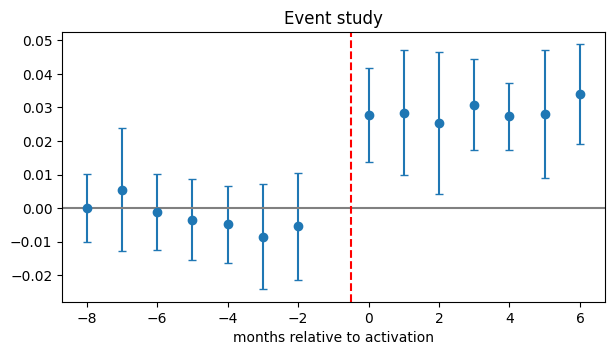

Placebo (activation shifted 6 months earlier, pre-period only): -0.0040  p=0.228


In [7]:
panel = pd.read_csv(f'{DATA}/injaz_regions_panel.csv')
naive_ba = panel[panel.activation_month>0].groupby('treated_post')['completion_rate'].mean()
print(f"Naive before/after in treated regions: {naive_ba[1]-naive_ba[0]:+.4f}  (rising national trend inflates this)")
did = smf.ols('completion_rate ~ treated_post + C(region) + C(month)', data=panel).fit(
    cov_type='cluster', cov_kwds={'groups': panel['region']})
lo, hi = did.conf_int().loc['treated_post']
print(f"TWFE DiD: {did.params['treated_post']:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]")

ev = panel[panel.activation_month > 0].copy()
ev['rel'] = (ev['month'] - ev['activation_month']).clip(-8, 6)
es = smf.ols('completion_rate ~ C(rel, Treatment(reference=-1)) + C(region) + C(month)', data=ev).fit(
    cov_type='cluster', cov_kwds={'groups': ev['region']})
coefs = {int(k.split('T.')[1].rstrip(']')): (es.params[k], *es.conf_int().loc[k]) for k in es.params.index if 'C(rel' in k}
xs = sorted(coefs); est = [coefs[x][0] for x in xs]; lo_ = [coefs[x][1] for x in xs]; hi_ = [coefs[x][2] for x in xs]
plt.errorbar(xs, est, yerr=[np.array(est)-np.array(lo_), np.array(hi_)-np.array(est)], fmt='o', capsize=3)
plt.axhline(0, color='grey'); plt.axvline(-0.5, ls='--', color='red'); plt.xlabel('months relative to activation'); plt.title('Event study'); plt.show()

pl = panel[(panel.activation_month > 0) & (panel.month < panel.activation_month)].copy()
pl['fake_post'] = (pl['month'] >= pl['activation_month'] - 6).astype(int)
placebo = smf.ols('completion_rate ~ fake_post + C(region) + C(month)', data=pl).fit(cov_type='cluster', cov_kwds={'groups': pl['region']})
print(f"Placebo (activation shifted 6 months earlier, pre-period only): {placebo.params['fake_post']:+.4f}  p={placebo.pvalues['fake_post']:.3f}")

## Step 6 - Tabulate all estimates against ground truth and explain each gap
The instructor file `data/ground_truth.json` holds the planted effects. Fill the reconciliation table, then write one sentence per row naming the assumption it relies on.

In [8]:
import json
truth = json.load(open(f'{DATA}/ground_truth.json'))
true_att = truth['injaz_users.csv']['true_ATT_realised']
tab = pd.DataFrame([
    {'method': 'Naive difference', 'estimate': naive, 'assumption': 'none (invalid)'},
    {'method': 'Outcome regression (g-formula)', 'estimate': g_ate, 'assumption': 'ignorability given ADJ + correct outcome model'},
    {'method': 'Stabilised IPW (trimmed)', 'estimate': ipw['ate'], 'assumption': 'ignorability given ADJ + correct propensity model + overlap'},
    {'method': 'AIPW cross-fit', 'estimate': dr['ate'], 'assumption': 'ignorability given ADJ; either nuisance model correct'},
    {'method': 'Mediator-controlled (WRONG)', 'estimate': m_bad.params['enrolled'], 'assumption': 'answers a different (direct-effect) question'},
])
tab['truth'] = true_att; tab['gap'] = tab['estimate'] - tab['truth']
print(tab.round(4).to_string(index=False))
print(f"\nDiD reminder effect {did.params['treated_post']:+.4f} vs planted {truth['injaz_regions_panel.csv']['true_DiD_effect']:+.4f} (assumption: parallel trends)")

                        method  estimate                                                  assumption  truth     gap
              Naive difference    0.1208                                              none (invalid) 0.0445  0.0763
Outcome regression (g-formula)    0.0404              ignorability given ADJ + correct outcome model 0.0445 -0.0042
      Stabilised IPW (trimmed)    0.0449 ignorability given ADJ + correct propensity model + overlap 0.0445  0.0003
                AIPW cross-fit    0.0450       ignorability given ADJ; either nuisance model correct 0.0445  0.0004
   Mediator-controlled (WRONG)    0.0224                answers a different (direct-effect) question 0.0445 -0.0221

DiD reminder effect +0.0297 vs planted +0.0320 (assumption: parallel trends)


## Step 7 - Written reconciliation
For each method write one sentence: which assumption it leans on, and why its number sits where it does relative to the truth. Then answer: which single unmeasured variable would break the adjustment-based estimates, and what would you do about it?

*Your answer:*

...

### Fast finishers
1. Sensitivity: compute the E-value for the AIPW risk ratio (`e_value(rr)` in causal_utils).
2. Collider demo: generate two independent traits and a collider `completed = skill + effort + noise > 1`; show the correlation between the traits goes from 0 to negative once you condition on `completed == 1`.
3. IV: use `distance_km` as an instrument for `online_filing` (2SLS via `linearmodels` if installed, otherwise the Wald ratio on a binarised instrument). Report the first-stage F.